In [1]:
%matplotlib inline

# Minimal example for using scLKMEWrapper class

In [2]:
%reload_ext autoreload
%autoreload 2

import warnings
warnings.simplefilter("ignore")


import sclkme
from SCLKMEWrapper import SCLKMEWrapper
import squidpy
import squidpy
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad

import matplotlib.pyplot as plt


from sklearn.ensemble import RandomForestClassifier


sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=80, facecolor='white')
sc.logging.print_header()

scanpy==1.9.3 anndata==0.9.1 umap==0.5.1 numpy==1.23.5 scipy==1.11.1 pandas==1.5.3 scikit-learn==1.4.2 statsmodels==0.14.0 python-igraph==0.10.8 pynndescent==0.5.11


In [3]:
#Load annotated dataset:
adata = squidpy.datasets.seqfish()
adata.obs['pos']=[int(item.split('_')[1][3:]) for item in adata.obs.index]

rng = np.random.default_rng(42)
labels = rng.integers(0,3,29)
label_dictionary = dict(zip(adata.obs.pos.unique(),labels))

adata.obs['groundtruth']=[label_dictionary[item] for item in adata.obs.pos]

print(adata)

AnnData object with n_obs × n_vars = 19416 × 351
    obs: 'Area', 'celltype_mapped_refined', 'pos', 'groundtruth'
    uns: 'celltype_mapped_refined_colors'
    obsm: 'X_umap', 'spatial'


Assume we want to split this dataset into training and testing sets, with positions 0-20 being training samples and 21-28 being testing samples. For example purposes, our labels of interest were randomly generated. We want the sketched landmark cells to come only from the training set.

We can use the scLKMEWrapper class to accomplish this:

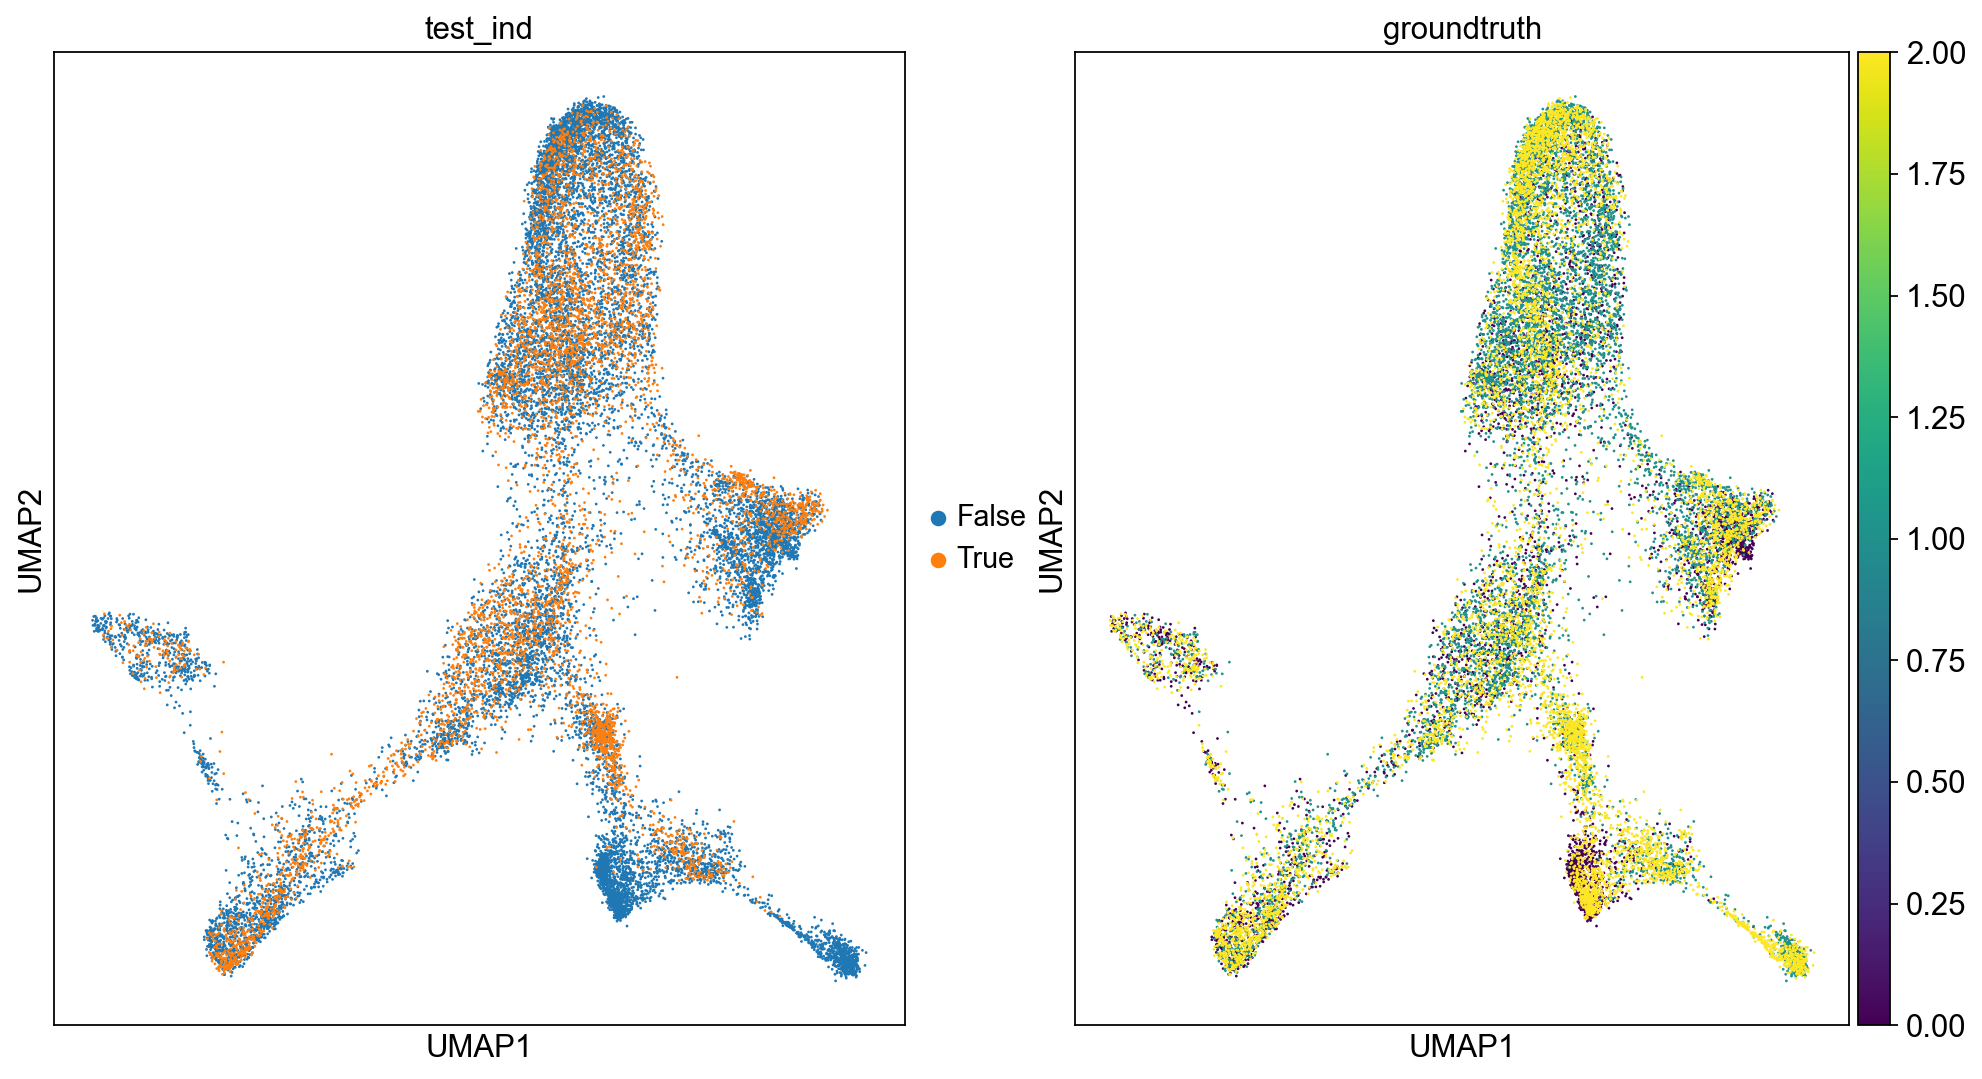

In [4]:
test_ind = adata.obs['pos'].values.astype(int)>20
adata.obs['test_ind']=pd.Categorical(test_ind)

fig,ax = plt.subplots(1,2,figsize=(15,8))
sc.pl.umap(adata,color='test_ind',ax=ax[0], show=False)
sc.pl.umap(adata,color='groundtruth',ax=ax[1], show=True)

In [5]:
if type(adata.X) is not np.ndarray:
    adata.X = adata.X.toarray()

adata_train = adata[~test_ind].copy()
print(adata_train)
adata_test = adata[test_ind].copy()
print(adata_test)

AnnData object with n_obs × n_vars = 14095 × 351
    obs: 'Area', 'celltype_mapped_refined', 'pos', 'groundtruth', 'test_ind'
    uns: 'celltype_mapped_refined_colors', 'test_ind_colors'
    obsm: 'X_umap', 'spatial'
AnnData object with n_obs × n_vars = 5321 × 351
    obs: 'Area', 'celltype_mapped_refined', 'pos', 'groundtruth', 'test_ind'
    uns: 'celltype_mapped_refined_colors', 'test_ind_colors'
    obsm: 'X_umap', 'spatial'


In [6]:
partition_key='pos'
use_rep='X'
n_sketch=128
random_state=42
method='exact'
sketch_method='random'
    
    
# create instance of SCLKMEWrapper
sw = SCLKMEWrapper(partition_key=partition_key,
                   use_rep=use_rep,
                   n_sketch=n_sketch,
                   random_state=random_state,
                   method=method,
                   sketch_method=sketch_method)

# fit sclkme on training data
X_train = sw.fit_transform(adata_train)

# map X_test into the sclkme space
X_test = sw.transform(adata_test)

In [7]:
X_train.head(3)

,X_kme_0,X_kme_1,X_kme_2,X_kme_3,X_kme_4,X_kme_5,X_kme_6,X_kme_7,X_kme_8,X_kme_9,...,X_kme_118,X_kme_119,X_kme_120,X_kme_121,X_kme_122,X_kme_123,X_kme_124,X_kme_125,X_kme_126,X_kme_127
pos,,,,,,,,,,,,,,,,,,,,,
0,0.811298,0.758088,0.764480,0.616015,0.795912,0.726776,0.600946,0.766022,0.716264,0.703455,...,0.714579,0.794018,0.633861,0.802516,0.793374,0.487877,0.632845,0.621346,0.386454,0.605441
1,0.818907,0.766569,0.770126,0.567057,0.793688,0.688774,0.549472,0.740631,0.677845,0.733993,...,0.710390,0.812200,0.637388,0.819014,0.808375,0.485671,0.639087,0.634616,0.379492,0.621025
2,0.861746,0.815263,0.819040,0.572584,0.829977,0.705412,0.547733,0.784018,0.683326,0.752786,...,0.740297,0.863195,0.671794,0.872463,0.857650,0.504742,0.679205,0.670707,0.378960,0.650482


In [8]:
X_test.head(3)

,X_kme_0,X_kme_1,X_kme_2,X_kme_3,X_kme_4,X_kme_5,X_kme_6,X_kme_7,X_kme_8,X_kme_9,...,X_kme_118,X_kme_119,X_kme_120,X_kme_121,X_kme_122,X_kme_123,X_kme_124,X_kme_125,X_kme_126,X_kme_127
pos,,,,,,,,,,,,,,,,,,,,,
21,0.850884,0.797208,0.801204,0.592210,0.829575,0.718479,0.561701,0.784166,0.686547,0.748781,...,0.747095,0.853095,0.689607,0.855517,0.85117,0.505373,0.669441,0.660862,0.408211,0.663778
22,0.867303,0.812884,0.816650,0.601064,0.849243,0.721774,0.560092,0.791527,0.692320,0.762117,...,0.755336,0.862062,0.686870,0.873743,0.86163,0.516306,0.682358,0.668314,0.386708,0.658639
23,0.798262,0.747603,0.752753,0.564586,0.780455,0.686385,0.562757,0.741456,0.676854,0.706656,...,0.713172,0.813013,0.710203,0.797340,0.81984,0.516880,0.652710,0.635582,0.445951,0.676564


Now we have sample-level embedding vectors based on landmark cells specifically from the training set, which prevents the possible data leakage that you would get from sketching on the full dataset.

In [9]:
adata_sample_level = ad.AnnData(pd.concat([X_train,X_test],axis=0))
adata_sample_level.obs['train_test']=['train']*21+['test']*8

         Falling back to preprocessing with `sc.pp.pca` and default params.


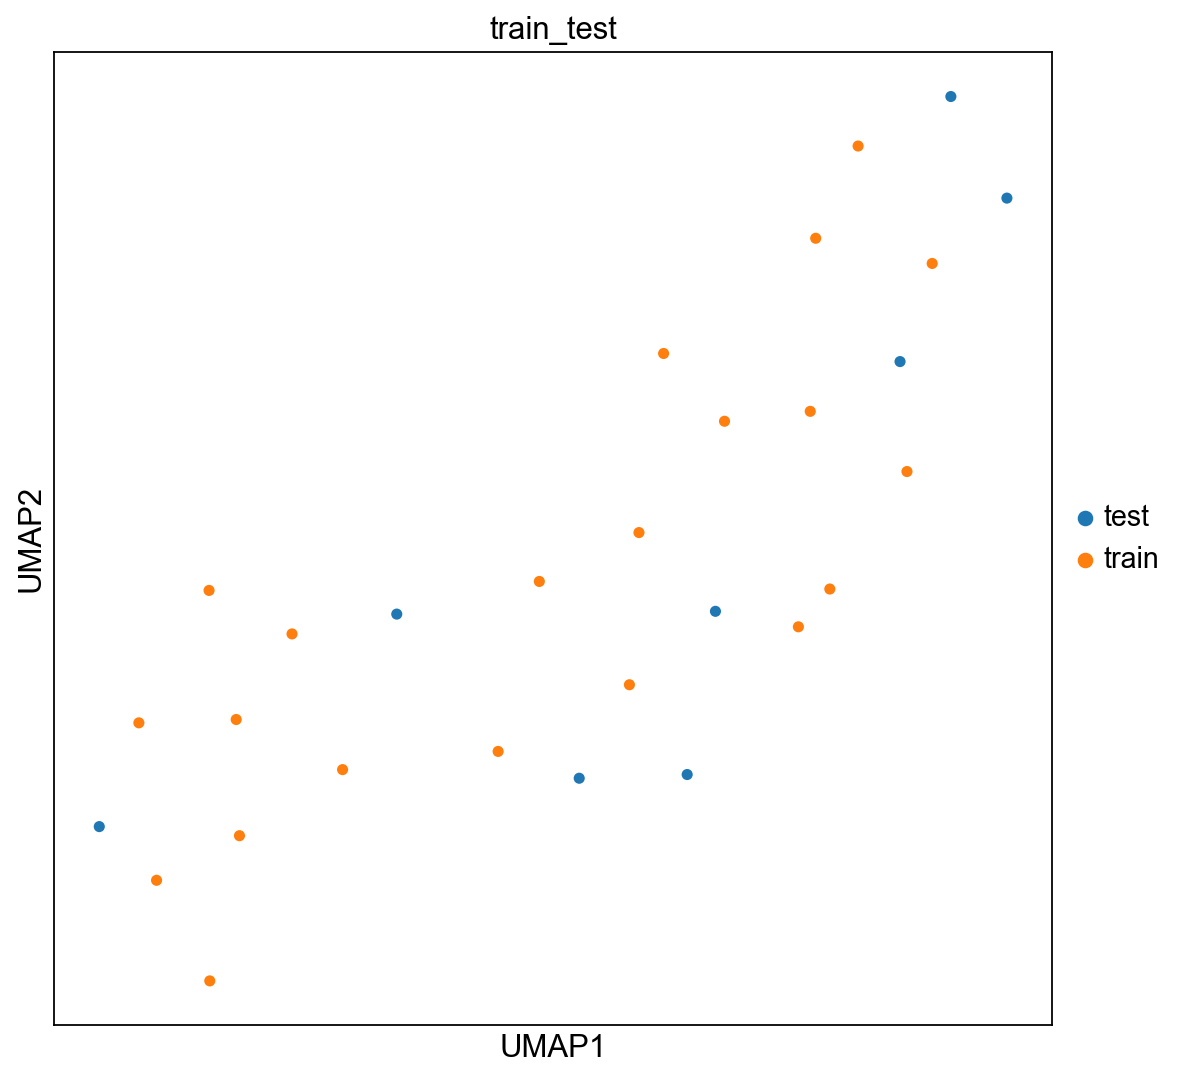

In [10]:
sc.pp.neighbors(adata_sample_level)
sc.tl.umap(adata_sample_level)
fig,ax=plt.subplots(figsize=(8,8))
sc.pl.umap(adata_sample_level,color='train_test',size=100,ax=ax)